In [45]:
# Force high-resolution output
%config InlineBackend.figure_format = 'retina'

### 1. 可视化项目（1）：议题注意力变化

#### 1.0 数据准备
注：因原始数据集过大（500MB），已提前截取了2021年10月-2022年6月之间的推文，并保存为了python可以快速读取的.parquet格式。

##### 1.0.1 导入原始数据集

In [175]:
import pandas as pd
import os

filename = "congress_tweets_2110_2206.parquet"
folder = "../data/large_file/congress_tweets"
filepath = os.path.join(folder, filename)

tweets = pd.read_parquet(filepath)

In [176]:
tweets.columns

Index(['OGC_FID', 'username', 'lastName', 'firstName', 'chamber', 'party',
       'state', 'district', 'dateAssumedOffice', 'gender', 'daysInOffice',
       'yearsInOffice', 'followersCount', 'tweetIndex', 'date', 'year',
       'month', 'day', 'period', 'content', 'renderedContent', 'url', 'id',
       'user', 'replyCount', 'retweetCount', 'likeCount', 'quoteCount',
       'conversationId', 'lang', 'source', 'sourceUrl', 'sourceLabel',
       'outlinks', 'tcooutlinks', 'media', 'retweetedTweet', 'quotedTweet',
       'inReplyToTweetId', 'inReplyToUser', 'mentionedUsers', 'coordinates',
       'place', 'hashtags', 'cashtags', 'delegitimization', 'autocracy',
       'conspiracism', 'ethnoNationalism', 'ADR'],
      dtype='str')

##### 1.0.2 识别是否为能源相关推特

In [177]:
# keywords_regex = "energy|energies|gas|LNG|crude oil|petro|diesel|hydrocarbon|fossil|electricity|fuel|renewable|nuclear|atomic|hydropower|battery|batteries|EV|electric vehicle|photovoltaic|PV"
keywords_regex = r"(?=.*?\b(?:energ(?:y|ies)|gas(?:oline|e?ous)?|LNG|LPG|crude(?: oil)?|petro\w*|diesel|oil(?:field| pipeline)?|hydrocarbon\w*|fossil|coal|refiner\w*|electric(?:ity| vehicle)?|fuels?|renewable\w*|nuclear|atomic|hydro(?:power|electric)?|batter(?:y|ies)|EVs?|photovoltaic|PV|solar|wind(?:mill| farm)?|hydrogen|biomass|biofuel\w*|geothermal|turbine\w*|grid|utility|utilities|decarbon\w*|cleantech|net[- ]?zero|ccus|climate change)\b)"
forbidden_regex = r"(?!.*(?:Iran|North Korea|Pyongyang|Tehran))"
combined_regex = r"^" + forbidden_regex + keywords_regex + r".*"

# Add a new column labeling whether the tweet is energy-related
tweets["is_energy"] = tweets["content"].str.contains(combined_regex, case=False, na=False)

# Check the number of original and retained entries
print(f"Total entries: {len(tweets)}")
print(f"Energy tweets: {sum(tweets['is_energy'])}")

Total entries: 318556
Energy tweets: 20329


In [178]:
# Data persistence
energy_tweets = tweets.query("is_energy == True")
energy_tweets.to_csv("../data/clean/energy_tweets.csv", index=False)

#### 1.1 基础图表可视化：时序、热图、直方图与核密度

##### 1.1.1 时间序列可视化：能源相关推特的总数、以及占总推特的比例随时间如何变化？

In [179]:
tweets.columns

Index(['OGC_FID', 'username', 'lastName', 'firstName', 'chamber', 'party',
       'state', 'district', 'dateAssumedOffice', 'gender', 'daysInOffice',
       'yearsInOffice', 'followersCount', 'tweetIndex', 'date', 'year',
       'month', 'day', 'period', 'content', 'renderedContent', 'url', 'id',
       'user', 'replyCount', 'retweetCount', 'likeCount', 'quoteCount',
       'conversationId', 'lang', 'source', 'sourceUrl', 'sourceLabel',
       'outlinks', 'tcooutlinks', 'media', 'retweetedTweet', 'quotedTweet',
       'inReplyToTweetId', 'inReplyToUser', 'mentionedUsers', 'coordinates',
       'place', 'hashtags', 'cashtags', 'delegitimization', 'autocracy',
       'conspiracism', 'ethnoNationalism', 'ADR', 'is_energy'],
      dtype='str')

Text(2022-03-25 00:00:00, 0.2, "2022-03-08: US imposed sanction on \nRussia's energy export")

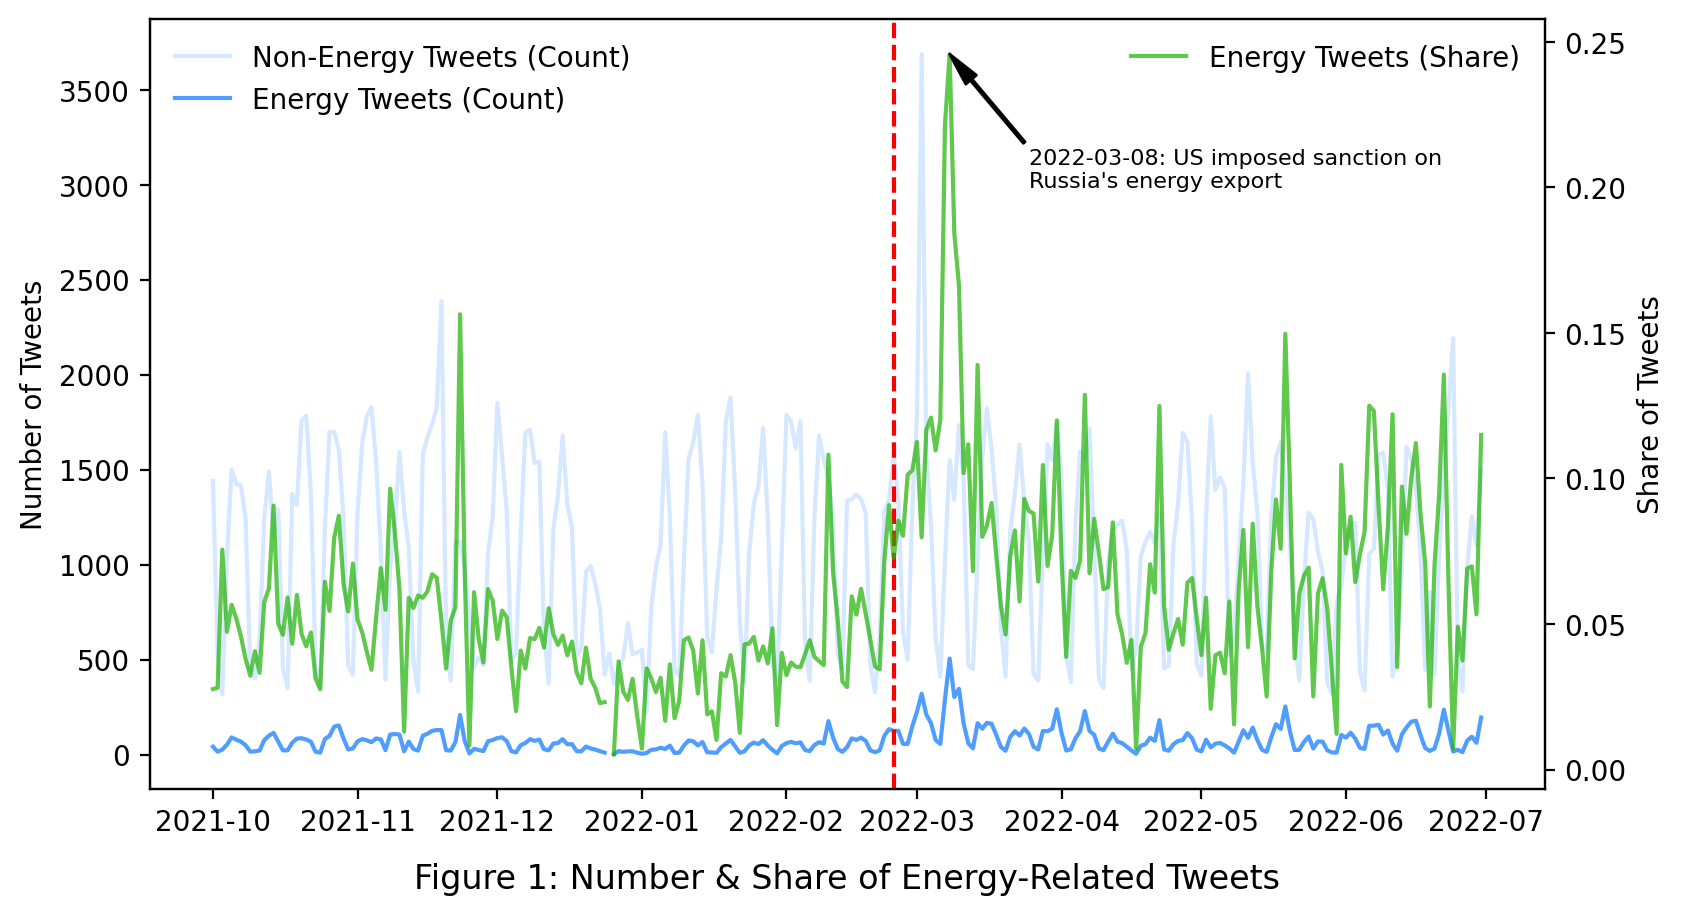

In [180]:
energy_share_daily = tweets.groupby(['year','month','day','is_energy'])['content'].count().unstack('is_energy')
energy_share_daily['energy_share'] = energy_share_daily[True]/(energy_share_daily[True] + energy_share_daily[False])
energy_share_daily.index = pd.to_datetime(energy_share_daily.index.get_level_values('year').astype(str) + "-" + 
                                          energy_share_daily.index.get_level_values('month').astype(str) + "-" + 
                                          energy_share_daily.index.get_level_values('day').astype(str))
energy_share_daily.columns = energy_share_daily.columns.astype(str)
energy_share_daily = energy_share_daily.rename(columns={
    'False': 'non_energy_num',
    'True': 'energy_num'
})

max_share = energy_share_daily[energy_share_daily['energy_share'] == max(energy_share_daily['energy_share'])]
max_share_value = max_share['energy_share'].iloc[0]
max_share_date = max_share.index[0]

# energy_share_daily.plot(kind='line', figsize=(9,5))
import matplotlib.pyplot as plt
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(9,5))
ax.plot(energy_share_daily.index, energy_share_daily['non_energy_num'],
        color="#0073FF29", label='Non-Energy Tweets (Count)')
ax.plot(energy_share_daily.index, energy_share_daily['energy_num'],
        color="#0073FFB0", label='Energy Tweets (Count)')
ax_secondy = ax.twinx() # Share the same x-axis, independent y-axis
ax_secondy.plot(energy_share_daily.index, energy_share_daily['energy_share'],
                color="#1CB202B3", linestyle = '-', label='Energy Tweets (Share)')
ax.axvline(x=pd.to_datetime('2022-02-24'),
           color='red', linestyle='--')

ax.set_ylabel('Number of Tweets')
ax_secondy.set_ylabel('Share of Tweets')
ax.set_title('Figure 1: Number & Share of Energy-Related Tweets', fontsize=12, y=-0.15)
ax.legend(loc='upper left', frameon=False)
ax_secondy.legend(loc='upper right', frameon=False)
ax_secondy.annotate(text="2022-03-08: US imposed sanction on \nRussia's energy export",
            xytext=(pd.to_datetime("2022-03-25"), 0.2), fontsize=8,
            xy=(max_share_date, max_share_value),
            arrowprops={'facecolor':'black', 'width':0.8, 'headwidth':5})
# ax.spines['top'].set_visible(False)
# ax_secondy.spines['top'].set_visible(False)

##### 1.1.2 热图：能源相关推特的总数、以及占总推特的比例在地理上有何异质性？

Text(0.5, -0.06, 'Figure 2: State-Level Heterogeneity of Attention to Energy Issues')

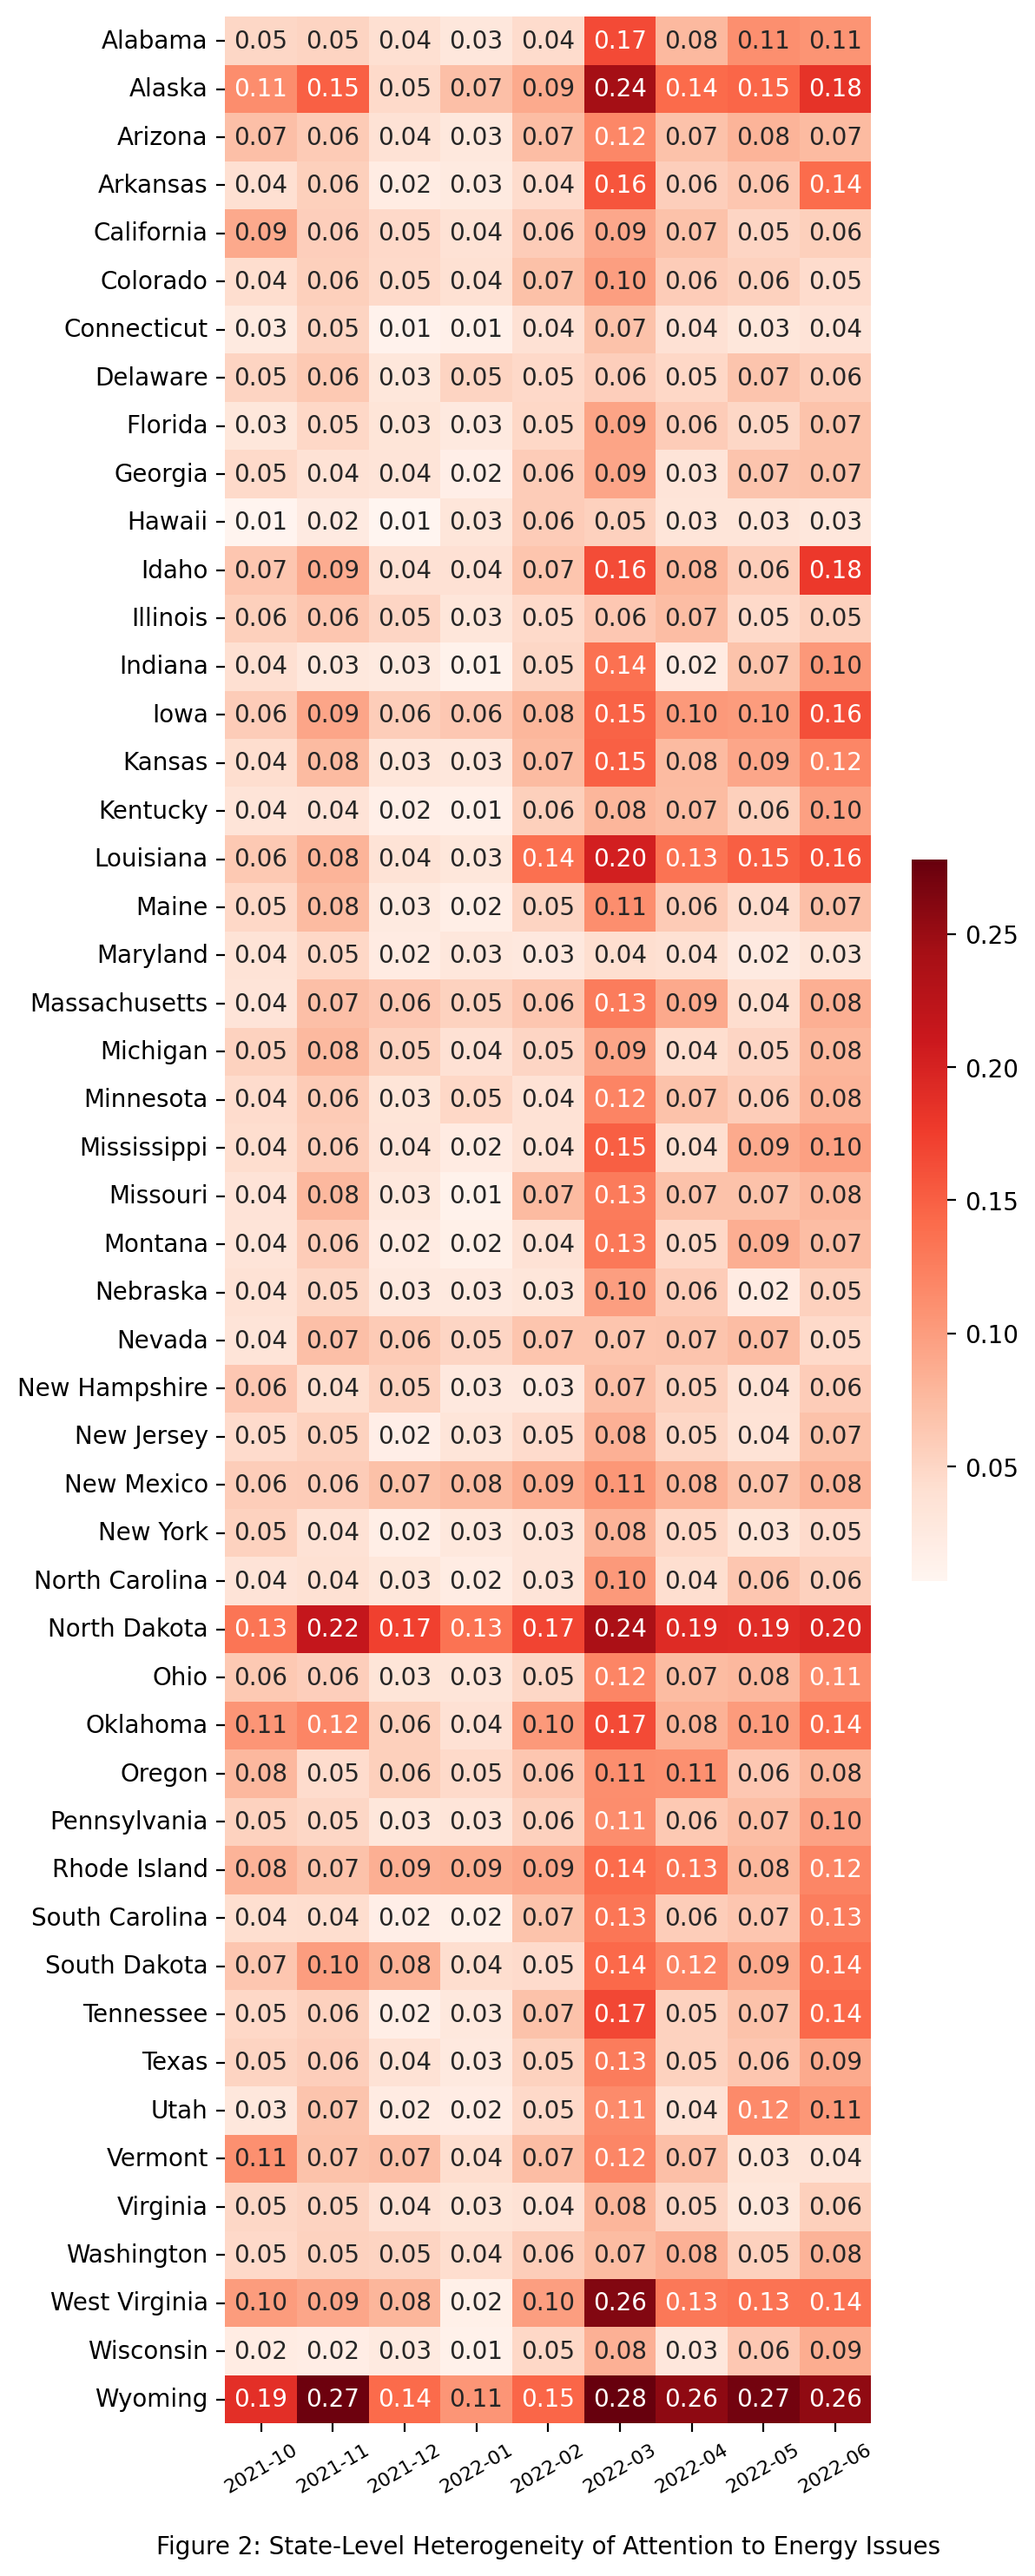

In [ ]:
import seaborn as sns
import matplotlib.dates as mdates
energy_share_monthly = tweets.groupby(['year','month','is_energy','state'])['content'].count().unstack(['is_energy'])
energy_share_monthly['energy_share'] = energy_share_monthly[True]/(energy_share_monthly[True] + energy_share_monthly[False])
energy_share_monthly = energy_share_monthly.unstack('state')
energy_share_monthly.index = pd.to_datetime(energy_share_monthly.index.get_level_values('year').astype(str) +
                                            '-' +
                                            energy_share_monthly.index.get_level_values('month').astype(str))
energy_share_monthly.index = energy_share_monthly.index.strftime("%Y-%m")
energy_share_monthly_state = energy_share_monthly['energy_share']
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,18))
sns.heatmap(ax=ax, data=energy_share_monthly_state.T, annot=True, fmt='.2f', cmap='Reds',
            cbar_kws={'shrink':0.3, 'orientation': 'vertical'}) # Reference: matplotlib.figure.Figure.colorbar
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30, labelsize=8)
ax.set_title("Figure 2: State-Level Heterogeneity of Attention to Energy Issues", fontsize=10,
             y=-0.06)

##### 3. 直方图与核密度图：不同政党议员议题注意力的差异？

In [231]:
tweets['tweet_date'] = pd.to_datetime(tweets['year'].astype(str) + '-' + tweets['month'].astype(str) + '-' + tweets['day'].astype(str))
tweets['is_postshock'] = tweets['tweet_date'] >= pd.to_datetime('2022-02-24')

Text(0.5, -0.2, 'Figure 3: Distribution of Energy Tweets Share among Congressmen by Party (Post-Shock)')

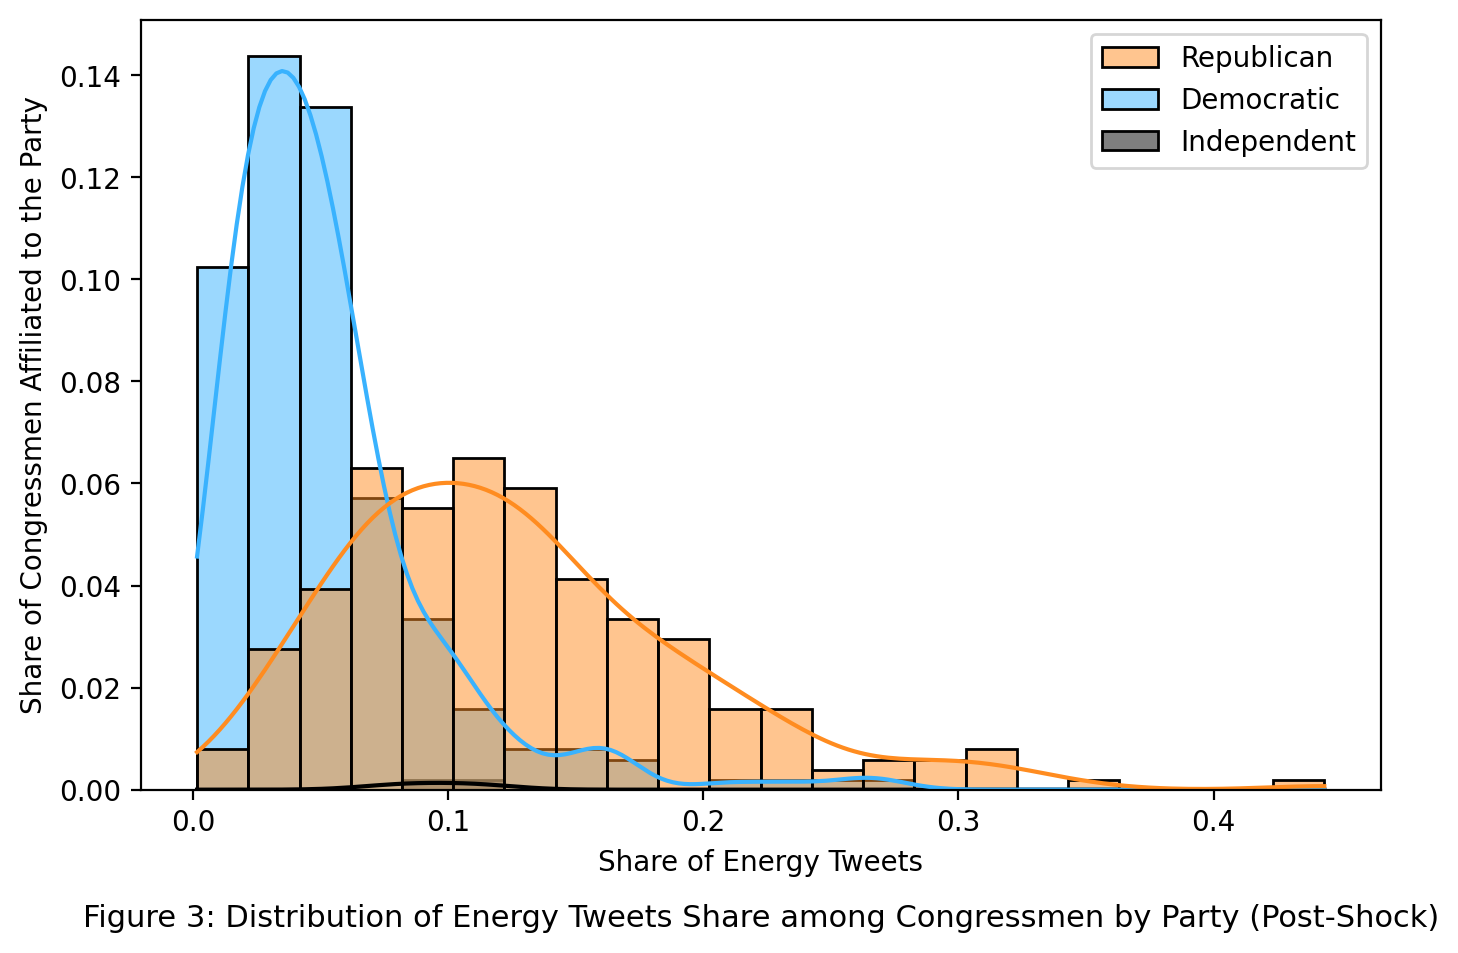

In [362]:
tweet_timefilter = tweets.query("is_postshock == True")
congressmen_behave = tweet_timefilter.groupby(['username','is_energy'])['content'].count().unstack('is_energy').reset_index()
congressmen_behave['energy_share'] = congressmen_behave[True]/(congressmen_behave[True] + congressmen_behave[False])
congressmen_party_mapping = tweets[['username','party']].drop_duplicates()
congressmen_behave = pd.merge(congressmen_behave, congressmen_party_mapping, how='inner', on='username')

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(8,5))
custom_palette = {'Republican':"#FF8C209F", 'Democratic':"#39B2FE76", 'Independent':"#00000029"}

sns.histplot(data=congressmen_behave, x='energy_share', hue='party', kde=True, stat='probability',
             palette=custom_palette, legend=True)
legend = ax.get_legend()
if legend:
    legend.set_title("")
ax.set_xlabel('Share of Energy Tweets')
ax.set_ylabel('Share of Congressmen Affiliated to the Party')
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
ax.set_title("Figure 3: Distribution of Energy Tweets Share among Congressmen by Party (Post-Shock)", y=-0.2, fontsize=11)

### 1.2 网络可视化：识别文本中的主题模式
问题：议员们在能源相关推特中具体讨论些什么？

In [183]:
import pandas as pd
import numpy as np
import spacy
import networkx as nx
from collections import Counter
from scipy.sparse import csr_matrix
from pyvis.network import Network

#### 1.2.0 文本预处理：推特文本→词共现矩阵（邻接表形式储存）

In [184]:
# Import energy tweets
energy_tweets = pd.read_csv("../data/clean/energy_tweets.csv")

1.2.0.1 **推特文本→核心词列表**
1. 去除不携带信息的词（停用词）与标点符号（词表筛选）
2. 去除过短的单词（长度筛选）
3. 仅保留名词、代词、动词、形容词（词性筛选）

In [185]:
# (~1m30s) Initiate accelerating pipeline. Turn off text parser and name entity recognizer.
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])
cleaned_tweets = []
for tweet in nlp.pipe(energy_tweets['content'], batch_size=1000, n_process=-1):
    retained_words = [word.lemma_.lower() for word in tweet
                      if not word.is_stop and not word.is_punct and len(word) > 2
                      and word.pos_ in ['NOUN','PROPN','VERB','ADJ']]
    cleaned_tweets.append(retained_words)
energy_tweets['retained_words'] = cleaned_tweets

# Data persistence
energy_tweets.to_csv("../data/clean/energy_tweets_wordlist.csv", index=False)

In [186]:
# Import data with word list
from ast import literal_eval
energy_tweets = pd.read_csv("../data/clean/energy_tweets_wordlist.csv",
                            converters={'retained_words':literal_eval})
energy_tweets['tweet_date'] = pd.to_datetime(energy_tweets['year'].astype(str) + '-' + energy_tweets['month'].astype(str) + '-' + energy_tweets['day'].astype(str))
energy_tweets.head(3)

,OGC_FID,username,lastName,firstName,chamber,party,state,district,dateAssumedOffice,gender,...,hashtags,cashtags,delegitimization,autocracy,conspiracism,ethnoNationalism,ADR,is_energy,retained_words,tweet_date
0,3,SenShelby,Shelby,Richard,Senate,Republican,Alabama,NaN,1987-01-03,M,...,NaN,NaN,0,0,0,0,N,True,"[scotu, decision, confirm, @epa, overstep, reg...",2022-06-30
1,15,SenShelby,Shelby,Richard,Senate,Republican,Alabama,NaN,1987-01-03,M,...,NaN,NaN,0,0,0,0,N,True,"[remain, concerned, inflation, continue, run, ...",2022-06-10
2,27,SenShelby,Shelby,Richard,Senate,Republican,Alabama,NaN,1987-01-03,M,...,NaN,NaN,0,0,0,0,N,True,"[join, @senategop, colleague, urge, secretary,...",2022-05-19


1.2.0.2 （提取推特文本子集）**核心词集→高频词集**

In [187]:
# Constructing subset of tweets (Grouping)
energy_tweets_subset = energy_tweets.query("party == 'Democratic' and tweet_date > '2022-02-24'")
# Indentifying most common words
all_words = [word for tweet in energy_tweets_subset['retained_words'] for word in tweet]
words_count_list = Counter(all_words)
common_words_list = [count_tuple[0] for count_tuple in words_count_list.most_common(100)]
# Indexing most common words
word_to_id = {word:index for index, word in enumerate(common_words_list)}
id_to_word = {index:word for index, word in enumerate(common_words_list)}
print(id_to_word)

{0: 'energy', 1: 'oil', 2: 'price', 3: 'gas', 4: 'amp', 5: 'climate', 6: 'clean', 7: 'fuel', 8: 'change', 9: 'big', 10: 'cost', 11: 'family', 12: 'pump', 13: 'work', 14: 'profit', 15: 'help', 16: 'company', 17: 'need', 18: 'act', 19: 'today', 20: 'putin', 21: 'american', 22: 'bill', 23: 'support', 24: 'fossil', 25: 'americans', 26: 'future', 27: 'lower', 28: 'pass', 29: 'time', 30: 'new', 31: 'russian', 32: 'high', 33: 'job', 34: 'community', 35: 'gouging', 36: 'pay', 37: 'ukraine', 38: 'low', 39: 'continue', 40: 'year', 41: 'tax', 42: 'record', 43: 'consumer', 44: 'action', 45: '@potus', 46: 'fight', 47: 'electric', 48: 'infrastructure', 49: 'protect', 50: 'legislation', 51: 'reduce', 52: 'economy', 53: 'vote', 54: 'war', 55: 'invest', 56: 'bipartisan', 57: 'people', 58: 'join', 59: 'russia', 60: 'create', 61: 'lead', 62: 'increase', 63: 'ban', 64: 'america', 65: 'solar', 66: 'crisis', 67: 'hold', 68: 'congress', 69: 'industry', 70: 'transition', 71: 'renewable', 72: 'bring', 73: 'wee

1.2.0.3 **核心词列表→高频词列表→词共现矩阵（邻接表形式存储）**

In [188]:
# Construct and store cooccurence network in adjacency list
cooccur_adjlist = Counter()
for tweet in energy_tweets_subset['retained_words']:
    valid_words_ids = [word_to_id[word] for word in tweet if word in common_words_list]
    valid_words_count = len(valid_words_ids)
    for i in range(valid_words_count):
        for j in range(i+1, valid_words_count):
            word_id_1, word_id_2 = valid_words_ids[i], valid_words_ids[j]
            if word_id_1 != word_id_2: # Exclude self-reference
                word_dyad = (word_id_1, word_id_2) if word_id_1 < word_id_2 else (word_id_2, word_id_1)
                cooccur_adjlist[word_dyad] = cooccur_adjlist[word_dyad] + 1
print(cooccur_adjlist)

Counter({(1, 2): 1558, (2, 3): 1491, (0, 6): 1193, (1, 3): 1094, (1, 9): 1066, (5, 8): 947, (1, 14): 839, (1, 16): 763, (0, 4): 732, (2, 35): 728, (2, 9): 683, (2, 12): 648, (2, 16): 594, (2, 14): 588, (1, 12): 558, (2, 11): 544, (1, 4): 542, (0, 1): 534, (0, 10): 516, (2, 32): 500, (7, 24): 494, (9, 14): 461, (3, 4): 451, (3, 12): 450, (3, 11): 441, (4, 5): 439, (0, 5): 438, (2, 4): 433, (2, 7): 432, (3, 16): 419, (1, 42): 404, (14, 16): 398, (0, 15): 397, (1, 35): 396, (3, 14): 389, (3, 10): 378, (2, 43): 378, (2, 42): 375, (1, 11): 373, (0, 2): 367, (1, 25): 362, (10, 11): 361, (2, 18): 361, (3, 9): 359, (1, 20): 356, (1, 31): 353, (2, 27): 349, (1, 32): 335, (0, 26): 330, (2, 10): 329, (0, 17): 324, (0, 3): 320, (14, 42): 320, (1, 43): 314, (0, 71): 312, (3, 41): 311, (2, 38): 311, (0, 33): 309, (4, 6): 306, (1, 41): 305, (0, 11): 302, (10, 27): 301, (0, 7): 291, (0, 13): 289, (3, 32): 287, (2, 25): 287, (3, 35): 286, (5, 6): 285, (2, 13): 283, (0, 70): 281, (0, 20): 280, (3, 27): 

#### 1.2.1 可视化制图

1.2.1.1 邻接表映射至网络对象（定义节点和边及其性质）、简化图形（仅显示高频节点与边）

In [ ]:
# Plot the network
## Map data to typological elements
G = nx.Graph()
for word, word_id in word_to_id.items():
    G.add_node(word, size=words_count_list[word] // 2)
cooccur_threshold = 500
common_words_num = len(common_words_list)
for (word_id_1, word_id_2), weight in cooccur_adjlist.items():
    if weight > cooccur_threshold:
        G.add_edge(id_to_word[word_id_1], id_to_word[word_id_2], weight=weight)

1.2.1.2 简化图形（仅显示最大联通分支）

In [382]:
## Retain only the largest connected component in network
lcc_node_list = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(lcc_node_list).copy()
print(f"Original nodes: {G.number_of_nodes()}; Retained nodes: {G_lcc.number_of_nodes()}")
print(f"Original edges: {G.number_of_edges()}; Retained edges: {G_lcc.number_of_edges()}")

Original nodes: 100; Retained nodes: 13
Original edges: 19; Retained edges: 18


1.2.1.3 映射至视觉元素（节点大小、连边色阶）

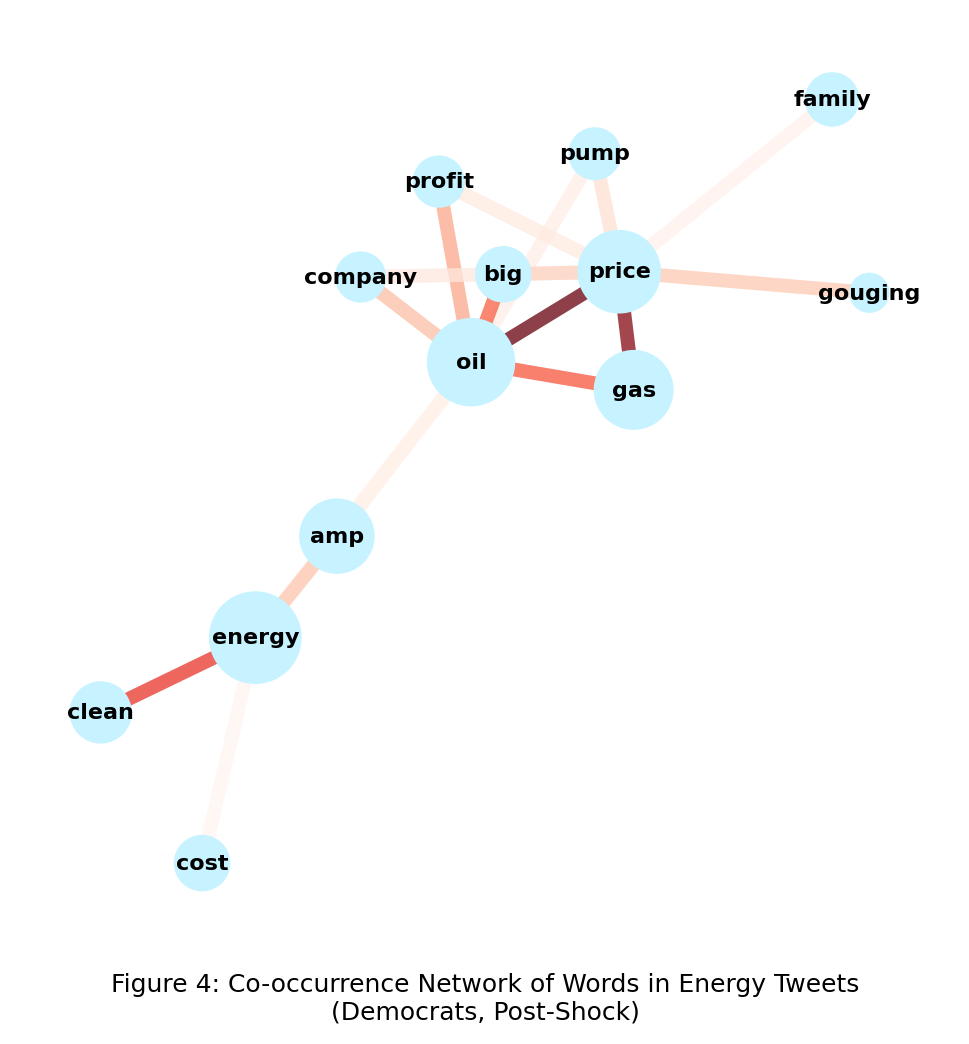

In [ ]:
## Define position (required parameter)
pos = nx.spring_layout(G=G_lcc, k=1.5, iterations=100, seed=41) # Force-directed layout
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,6))

nx.draw_networkx_nodes(
    G=G_lcc, pos=pos,
    node_size = [G_lcc.nodes[node]['size'] for node in G_lcc.nodes],
    node_color = "#C6F3FFFF",
    ax=ax
)
nx.draw_networkx_edges(
    G=G_lcc, pos=pos,
    edgelist=G_lcc.edges,
    edge_color=[G_lcc.edges[edge]['weight'] for edge in G_lcc.edges],
    edge_cmap=plt.cm.Reds,
    width=5,
    alpha=0.75,
    ax=ax
)
nx.draw_networkx_labels(
    G=G_lcc, pos=pos,
    font_size=8,
    font_weight='bold',
    ax=ax
)
ax.set_title(f"Figure 4: Co-occurrence Network of Words in Energy Tweets\n(Democrats, Post-Shock)", fontsize=9, y=-0.1)
for sp in ax.spines: ax.spines[sp].set_visible(False) 

### 2. 可视化项目（2）：含地理信息冲突事件数据

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from countrycode import countrycode, codelist

问题：2024年武装冲突事件的全球地理分布如何？

2.1 **如何直接将事件依据地理坐标绘制在地图上？**

In [23]:
# (~9s) Import UCDP-GED conflict event data
ucdp_ged = pd.read_csv("../data/large_file/UCDP_GED/GEDEvent_v26_1.csv") # gwnoa: Gleditsch and Ward number for Side A if the side is a state.  
# Import country boundary shapefile
world_shapefile_path = "zip://../data/large_file/natural_earth_boundaries/ne_50m_admin_0_countries.zip"
world_map = gpd.read_file(world_shapefile_path)
world_map_africa = world_map.query("CONTINENT == 'Africa'")

# (~1s) Convert longitude-latitude dyad into Geometry object identifiable to geopandas
ucdp_ged = gpd.GeoDataFrame(data=ucdp_ged, 
                            geometry=gpd.points_from_xy(x=ucdp_ged.longitude, y=ucdp_ged.latitude), # Note: Longitude first
                            crs='EPSG:4326') # Refer to codebook for coordinate reference system ID
ucdp_ged_africa = ucdp_ged.query("region == 'Africa'")

C:\Users\lenovo\AppData\Local\Temp\ipykernel_21428\3574996545.py:2: DtypeWarning: Columns (0: gwnoa) have mixed types. Specify dtype option on import or set low_memory=False.
  ucdp_ged = pd.read_csv("../data/large_file/UCDP_GED/GEDEvent_v26_1.csv") # gwnoa: Gleditsch and Ward number for Side A if the side is a state.


In [352]:
ucdp_ged.columns

Index(['id', 'relid', 'year', 'active_year', 'code_status', 'type_of_violence',
       'conflict_dset_id', 'conflict_new_id', 'conflict_name', 'dyad_dset_id',
       'dyad_new_id', 'dyad_name', 'side_a_dset_id', 'side_a_new_id', 'side_a',
       'side_b_dset_id', 'side_b_new_id', 'side_b', 'number_of_sources',
       'source_article', 'source_office', 'source_date', 'source_headline',
       'source_original', 'where_prec', 'where_coordinates',
       'where_description', 'adm_1', 'adm_2', 'latitude', 'longitude',
       'geom_wkt', 'priogrid_gid', 'country', 'country_id', 'region',
       'event_clarity', 'date_prec', 'date_start', 'date_end', 'deaths_a',
       'deaths_b', 'deaths_civilians', 'deaths_unknown', 'best', 'high', 'low',
       'gwnoa', 'gwnob', 'geometry'],
      dtype='str')

(np.float64(-29.17814208984375),
 np.float64(55.22682373046876),
 np.float64(-35.0),
 np.float64(40.0))

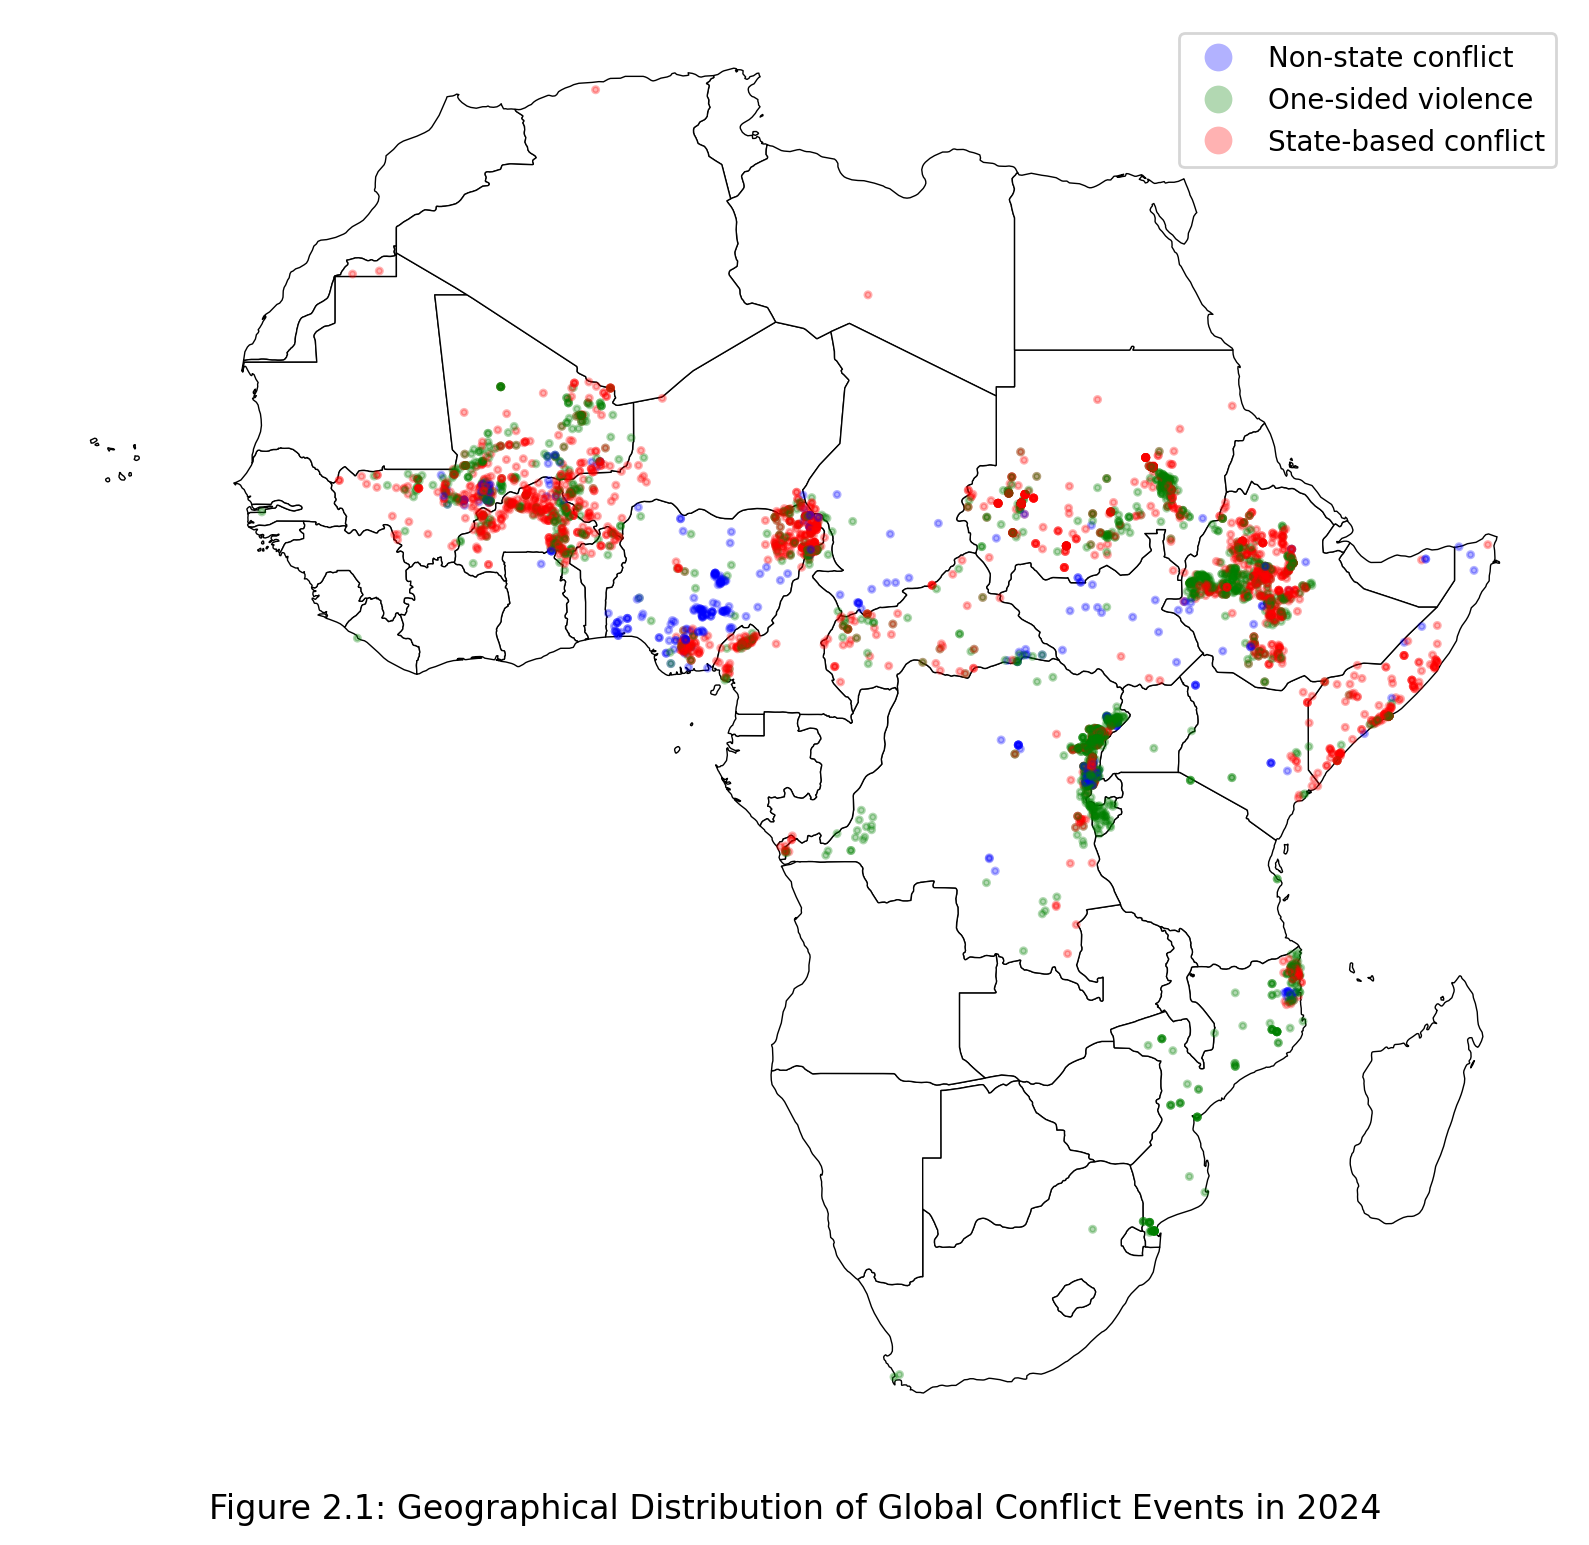

In [ ]:
from matplotlib.colors import ListedColormap
ucdp_ged_africa['type_of_violence_factor'] = ucdp_ged_africa['type_of_violence'].astype(str)
ucdp_ged_africa['type_of_violence_factor'] = ucdp_ged_africa['type_of_violence_factor'].replace(['1','2','3'],['State-based conflict','Non-state conflict','One-sided violence'])

# world_map_africa = world_map_africa.to_crs('EPSG:3857') # Web Mercator Projection
# ucdp_ged_africa = ucdp_ged_africa.to_crs('EPSG:3857')

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,10))
world_map_africa.plot(ax=ax, color='white', edgecolor='black', linewidth=0.5)
# ucdp_ged.query("year == 2024").plot(ax=ax, color="#ff6200ff", alpha=0.1, markersize=0.8)
ucdp_ged_africa.query("year == 2024").plot(ax=ax, column='type_of_violence_factor', alpha=0.3, markersize=5, legend=True,
                                    cmap=ListedColormap(['blue','green','red']))
# ax.set_xlim(-20,60); 
ax.set_ylim(-35, 40) # Remove Marion Island
ax.set_title("Figure 2.1: Geographical Distribution of Global Conflict Events in 2024", fontsize=12, y=-0.1)
ax.axis(False)

2.2 **如何汇总到国家层面观察分布？**

In [32]:
# Merge two datasets to aggregate number of events by country
# `country_id`: Gleditsch and Ward number (`gwn`) of the country (identifier in UCDP-GED)
# `country_id_iso3c`: ISO 3-character country-code (identifier in Natural Earth Map)
# (~7s) Translation: "countrycode" package
ucdp_ged_africa['country_id_iso3c'] = countrycode(list(ucdp_ged_africa.country_id), origin='gwn', destination='iso3c')
ucdp_ged_africa_2024 = ucdp_ged_africa.query("year==2024")

In [33]:
# Primary method: Merge on country name
country_level_merge_2024 = pd.merge(ucdp_ged_africa_2024, world_map_africa[['ISO_A3','geometry']], how='right',
                                    left_on='country_id_iso3c', right_on='ISO_A3')
country_level_count_2024 = country_level_merge_2024.groupby('ISO_A3')['id'].count().reset_index(name='event_num')
country_level_count_2024_geo = pd.merge(world_map_africa[['ISO_A3','geometry']], country_level_count_2024, how='left', on='ISO_A3')

In [34]:
# Alternative: YET NOT RECOMMENDED DUE TO PRECISION CONCERNS
country_level_merge_2024 = gpd.sjoin(ucdp_ged_africa_2024, world_map[['ISO_A3','geometry']], how="right", predicate="within")
country_level_count_2024 = country_level_merge_2024.groupby('ISO_A3')['id'].count().reset_index(name='event_num')
country_level_count_2024_geo = pd.merge(world_map_africa[['ISO_A3','geometry']], country_level_count_2024, how='left', on='ISO_A3')

In [35]:
country_level_count_2024_geo.sort_values('event_num', ascending=False).head(10)

,ISO_A3,geometry,event_num
35,ETH,"POLYGON ((35.26836 5.49229, 35.25244 5.51104, ...",883
41,COD,"POLYGON ((30.75117 -8.19365, 30.57793 -8.22002...",791
8,SDN,"POLYGON ((34.07812 9.46152, 34.07676 9.46152, ...",704
16,NGA,"MULTIPOLYGON (((7.30078 4.41816, 7.20391 4.387...",522
23,MLI,"POLYGON ((-11.3894 12.40439, -11.38242 12.4792...",441
49,BFA,"POLYGON ((0.90049 10.99326, 0.64297 10.98306, ...",313
19,MOZ,"POLYGON ((31.28789 -22.40205, 31.42949 -22.298...",179
47,CMR,"POLYGON ((8.55586 4.75522, 8.58516 4.83281, 8....",175
10,SOM,"POLYGON ((41.53271 -1.69531, 41.5376 -1.61318,...",161
45,CAF,"POLYGON ((24.14736 8.66562, 24.19482 8.65337, ...",99


Text(0.5, -0.1, 'Figure 2.2: Number of Conflict Events by Country in 2024')

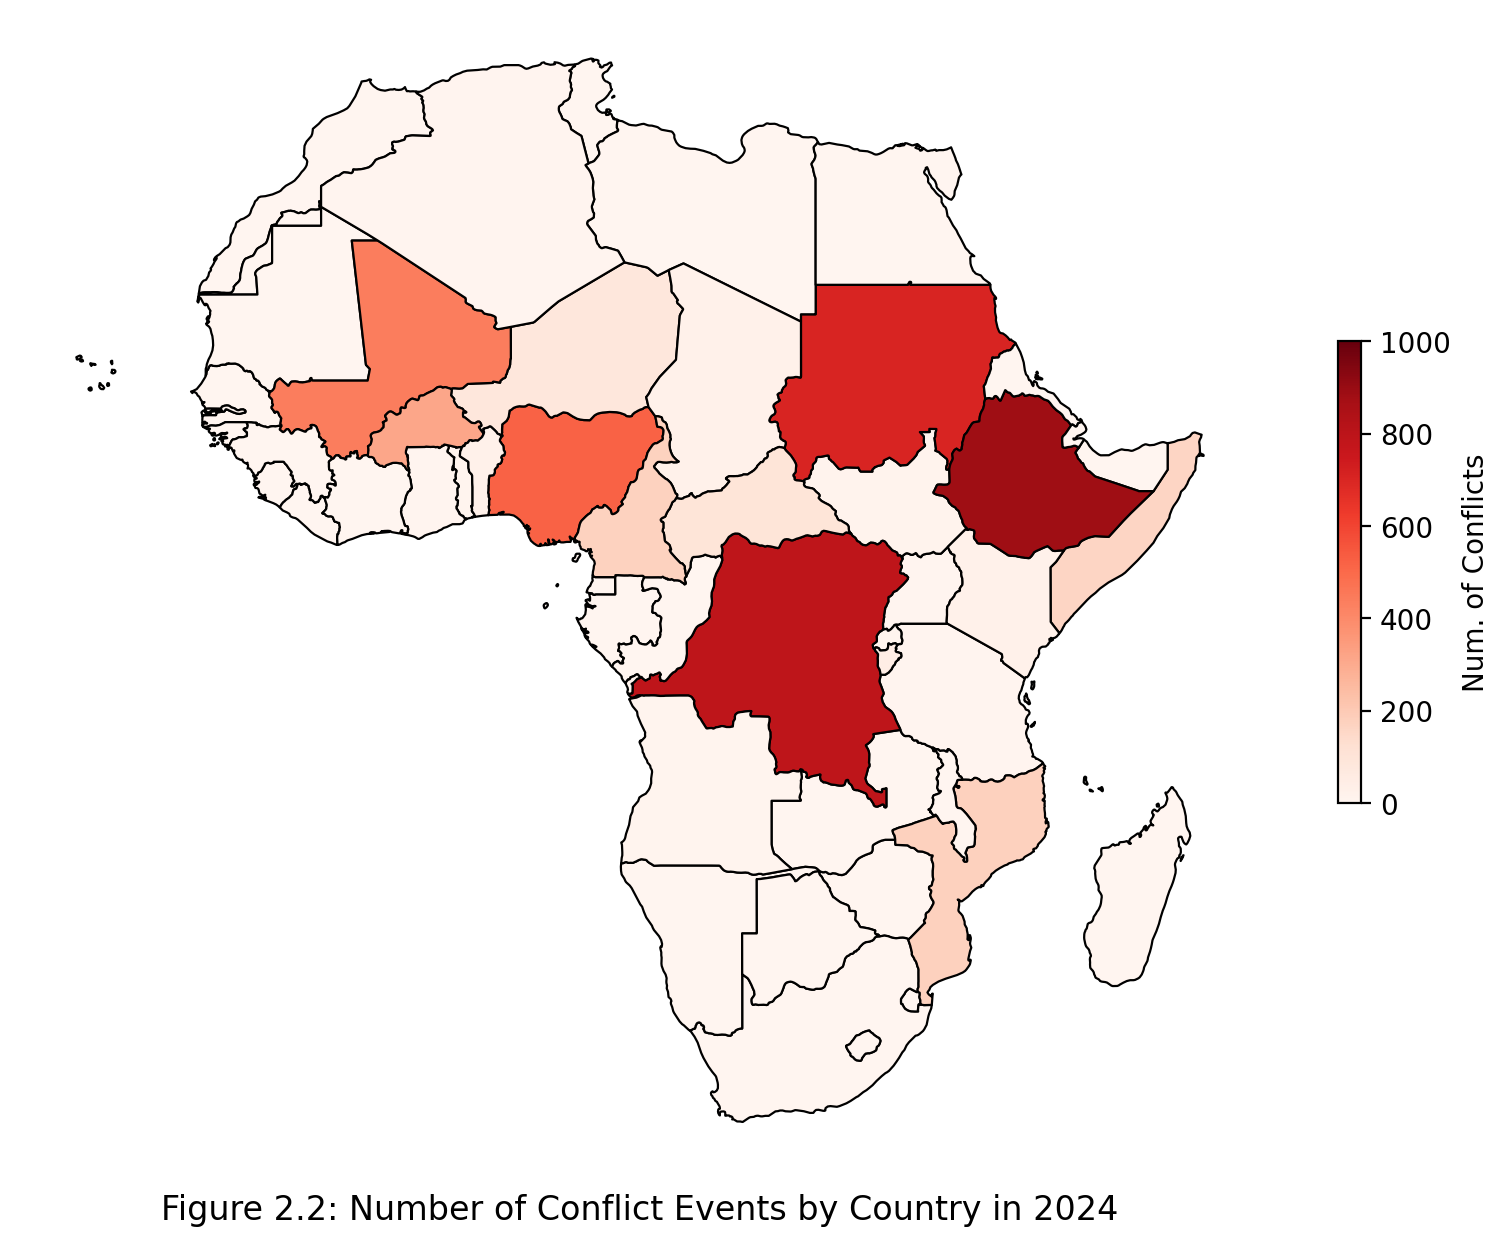

In [60]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,10))
country_level_count_2024_geo.plot(ax=ax, column='event_num', # Column must be specified
                                  cmap='Reds', edgecolor='black', linewidth=0.8, 
                                  legend=True, vmin=0, vmax=1000, legend_kwds={'shrink':0.3, 'orientation':'vertical', 'label':'Num. of Conflicts'})
ax.axis(False)
ax.set_ylim(-35,40)
ax.set_title("Figure 2.2: Number of Conflict Events by Country in 2024", fontsize=12, y=-0.1)

2.3 **如何汇总到地理网格层面？**

1. 导入底图网格（PRIO-GRID）

In [39]:
# Import PRIO-GRID boundary shapefile (without substantive data)
priogrid_shapefile_path = "zip://../data/large_file/natural_earth_boundaries/priogrid_cellshp.zip"
priogrid = gpd.read_file(priogrid_shapefile_path)
# Import PRIO-GRID grid-level data (CSV format)
priogrid_population = pd.read_csv("../data/large_file/natural_earth_boundaries/PRIO-GRID_population_2010.csv")
priogrid_population_shapefile = pd.merge(priogrid[['gid','geometry']], priogrid_population[['gid','pop_gpw_sum']])

In [40]:
priogrid_population_shapefile.sort_values('pop_gpw_sum',ascending=False).head(5)

,gid,geometry,pop_gpw_sum
38365,171155,"POLYGON ((77 28.5, 77 29, 77.5 29, 77.5 28.5, ...",18278156.0
33756,181360,"POLYGON ((139.5 35.5, 139.5 36, 140 36, 140 35...",18082582.0
53832,120814,"POLYGON ((106.5 -6.5, 106.5 -6, 107 -6, 107 -6...",17374444.0
41313,163981,"POLYGON ((90 23.5, 90 24, 90.5 24, 90.5 23.5, ...",16541525.0
41868,162537,"POLYGON ((88 22.5, 88 23, 88.5 23, 88.5 22.5, ...",15778912.0


2. 添加六边形地理网格并计数

(np.float64(91.525),
 np.float64(101.975),
 np.float64(8.525),
 np.float64(29.975))

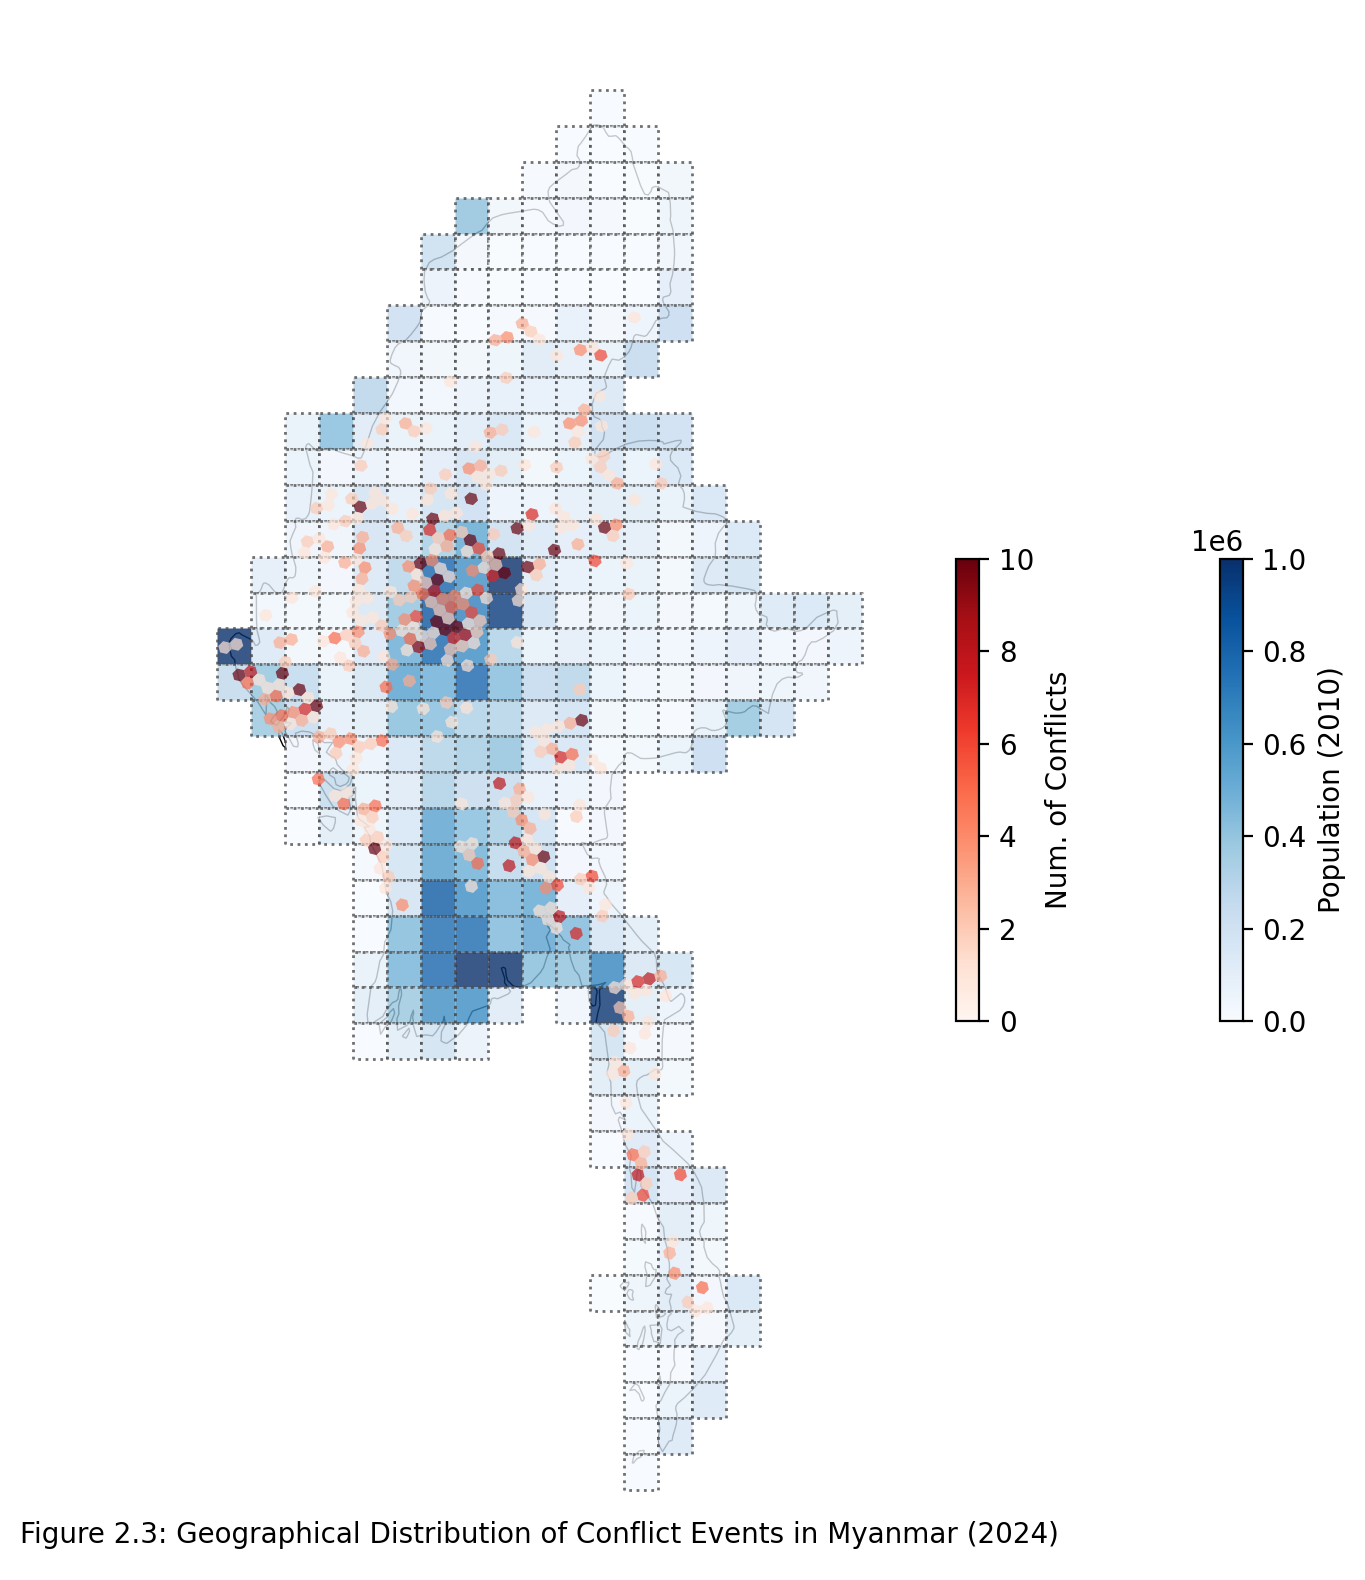

In [46]:
import h3pandas
ucdp_ged['country_id_iso3c'] = countrycode(list(ucdp_ged.country_id), origin='gwn', destination='iso3c')
ucdp_ged_2024 = ucdp_ged.query("year==2024")
ucdp_ged_2024_country = ucdp_ged_2024.query("country_id_iso3c in 'MMR'") # ['COD','UGA']

gdf_grid = ucdp_ged_2024_country[['id','geometry']].h3.geo_to_h3_aggregate(
    resolution=5,
    operation={'id': 'count'}
)

world_map_country = world_map.query("ISO_A3 in 'MMR'")
priogrid_population_shapefile_country = gpd.sjoin(priogrid_population_shapefile, world_map_country[['ISO_A3','geometry']], how='inner', predicate='intersects')

# Plotting map layer-by-layer
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,10))
world_map_country.plot(ax=ax, color='white', edgecolor='black', linewidth=0.5, label='ISO_A3')
priogrid_population_shapefile_country.plot(ax=ax, column='pop_gpw_sum', cmap='Blues', edgecolor='0.3', linestyle=':', alpha=0.8, legend=True,
                                           vmin=0, vmax=1e6, legend_kwds={'shrink': 0.3, 'label':'Population (2010)', 'orientation':'vertical'})
# ucdp_ged_2024_country.plot(ax=ax, color="#ffa600ff", alpha=1, markersize=3)
gdf_grid.plot(ax=ax, column='id', cmap='Reds', alpha=0.7, legend=True,
              vmin=0, vmax=10, legend_kwds={'shrink': 0.3, 'label': 'Num. of Conflicts'})
ax.set_title("Figure 2.3: Geographical Distribution of Conflict Events in Myanmar (2024)", y=0, fontsize=10)
ax.axis(False)